# Reading by windows & Decimation

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on Reading by windows, and Decimation.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [6]:
import rasterio
from rasterio.windows import Window
from rasterio.plot import show

import rioxarray

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
#path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## Reading by Windows

A Window is a subset of a raster.

It is particularly useful when working with big files to reduce memory usage and speed up processing times.

### • rasterio

In [3]:
ds_rasterio = rasterio.open(raster_path)

In rasterio, we can use the object *Window* to create one.

In the following case, we will create a subset of our image with 1500 rows x 1500 columns.

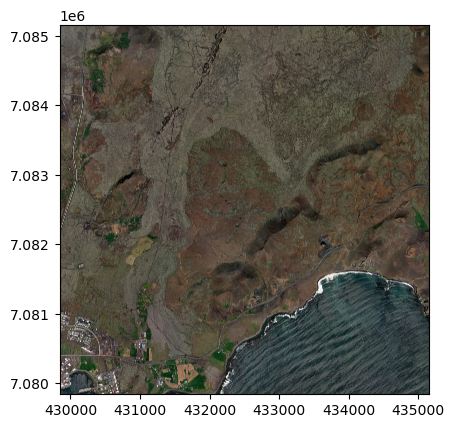

<Axes: >

In [4]:
show(ds_rasterio)

In [7]:
window = Window(col_off=1500, row_off=1500, width=1500, height=1500) #1500 x 1500

We will focus on the first band for our example.

In [8]:
b1 = ds_rasterio.read(1)

w = ds_rasterio.read(1, window=window)

Let's compare the full raster with the subset image created with the Window :

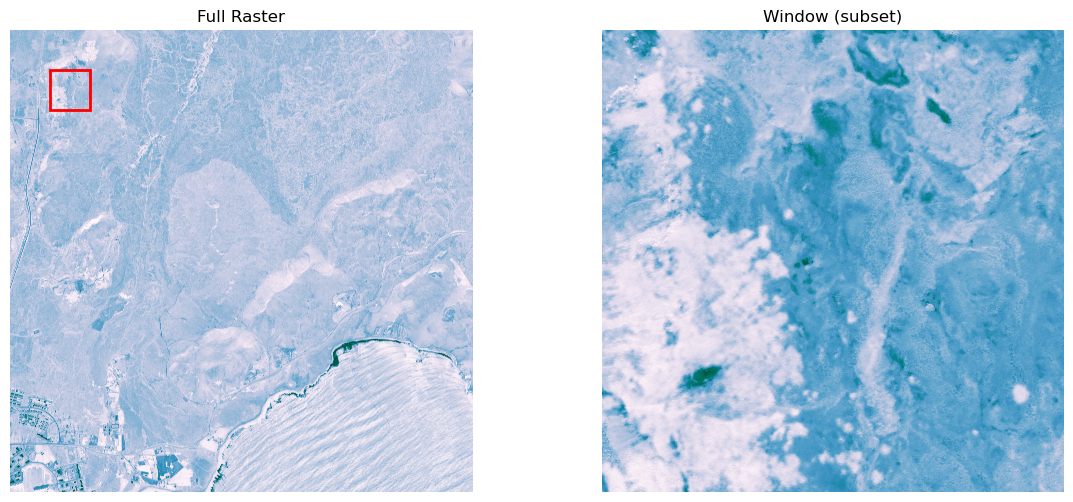

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#full raster
axes[0].imshow(b1, cmap="PuBuGn")
axes[0].set_title("Full Raster")
axes[0].axis("off")

#rectangle
rect = patches.Rectangle(
    (window.col_off, window.row_off),
    window.width,
    window.height,
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)

#window raster
axes[1].imshow(w, cmap="PuBuGn")
axes[1].set_title("Window (subset)")
axes[1].axis("off")

plt.show()

### • rioxarray

In [10]:
ds_rioxarray = rioxarray.open_rasterio(raster_path)

With rioxarray, we can use isel_window() - https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.rioxarray.XRasterBase.isel_window - to create a subset of our image. 

As an argument, we will pass our Window previously created to select the extents of the new raster :

In [11]:
window

Window(col_off=1500, row_off=1500, width=1500, height=1500)

In [12]:
rioxarray_subset = ds_rioxarray.rio.isel_window(window)

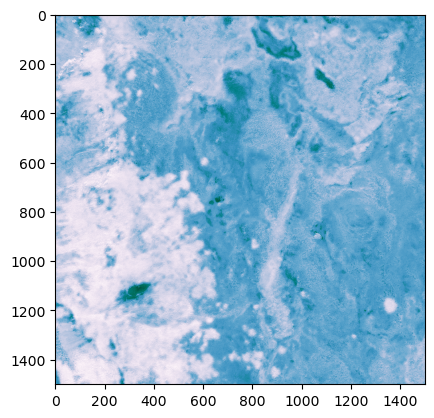

<Axes: >

In [15]:
show(rioxarray_subset.sel(band=1), cmap="PuBuGn")

## Decimation

Decimation is used to reduce the image resolution of a raster by skipping a certain amount of pixels in rows, columns or both.

It is particularly useful to speed up the display or analyze large raster files.

### • rasterio

In the following case, we will reduce the size by half (height and width). 

Our raster's size is 17408 x 17408, so we want to reshape it as 8704 x 8704. 

We can do so by using the *read()* function - https://rasterio.readthedocs.io/en/stable/api/rasterio._io.html#rasterio._io.DatasetReaderBase.read - but we will use the *out_shape* argument to select the extent we want to keep :

In [21]:
decimated_b1 = ds_rasterio.read(1, out_shape=(8704, 8704))

We can now plot the decimated raster :

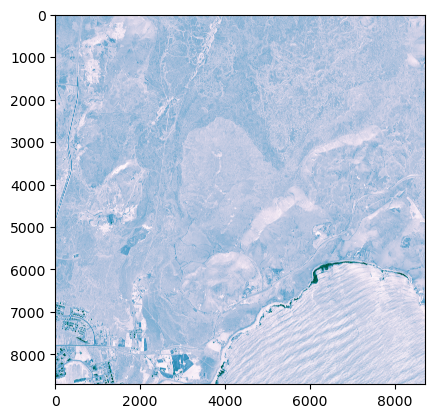

<Axes: >

In [23]:
show(decimated_b1, cmap="PuBuGn")